## 1. Imports

In [49]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.datasets import load_iris

plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')


## 2. Load the Iris Dataset

In [50]:
# Load iris from sklearn
iris = load_iris()

# Build a DataFrame for easy exploration
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target_names[iris.target]

print("Shape of the dataset :", data.shape)
data.head()


Shape of the dataset : (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [51]:
data.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [52]:
data.sample(3, random_state=42)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica


In [53]:
data.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [54]:
# Check for nulls
print("Any nulls?", data.isnull().any().any())


Any nulls? False


## 3. Feature Selection
We use **Petal Length** and **Petal Width** — these two features give the
cleanest cluster separation in Iris (analogous to Annual Income & Spending Score
in the Mall dataset).


In [55]:
# Select petal length and petal width (columns 2 and 3)
x = data[['petal length (cm)', 'petal width (cm)']].values
print("Feature matrix shape:", x.shape)

x_data = pd.DataFrame(x, columns=['petal length (cm)', 'petal width (cm)'])
x_data.head()


Feature matrix shape: (150, 2)


,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


## 4. The Elbow Method

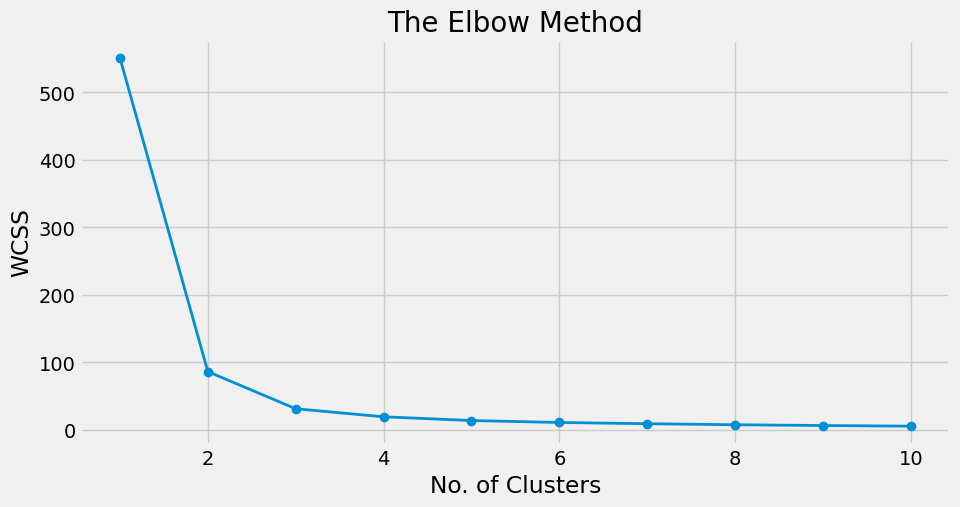

In [56]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, 'o-', linewidth=2)
plt.title('The Elbow Method', fontsize=20)
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


## 5. Cluster Visualisation (k = 3)
The elbow typically falls at k = 3 for Iris — matching its three species.


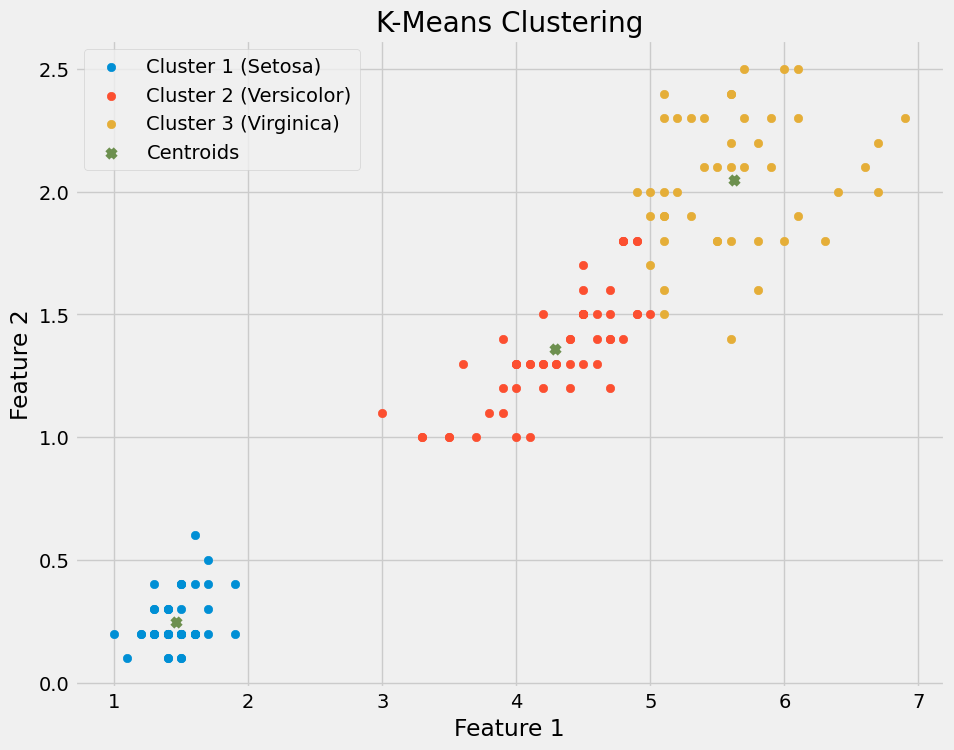

In [57]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Apply KMeans
km = KMeans(n_clusters=3)
y = km.fit_predict(x)

labels  = ['Cluster 1 (Setosa)', 'Cluster 2 (Versicolor)', 'Cluster 3 (Virginica)']

# Plot clusters
for i in range(3):
    plt.scatter(x[y == i, 0], x[y == i, 1], label=labels[i])

# Plot centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            marker='x', label='Centroids')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.legend()

plt.show()

## 7. Silhouette Analysis

In [63]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

print(f'Feature matrix shape: {X_scaled.shape}')


Feature matrix shape: (150, 2)


k=2, score=0.743
k=3, score=0.674
k=4, score=0.599
k=5, score=0.575
k=6, score=0.428


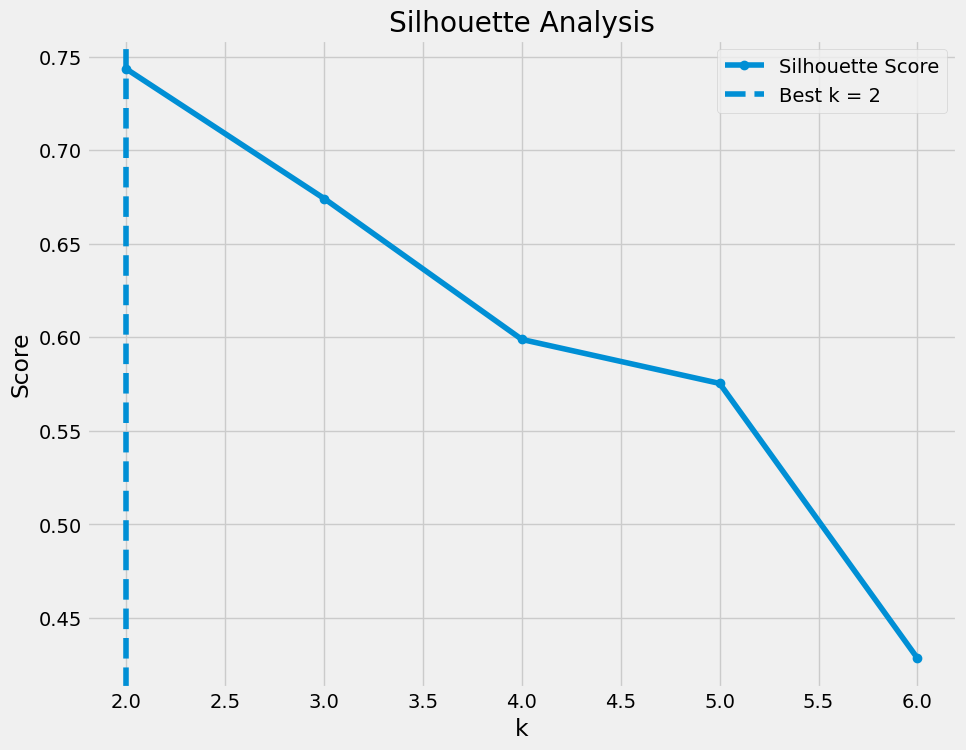

Best k = 2


In [65]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

k_values = [2, 3, 4, 5, 6]
scores = []

# Compute silhouette scores
for k in k_values:
    labels = KMeans(n_clusters=k).fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores.append(score)
    print(f"k={k}, score={score:.3f}")

# Find best k
best_k = k_values[np.argmax(scores)]

# Plot
plt.plot(k_values, scores, marker='o', label='Silhouette Score')
plt.axvline(best_k, linestyle='--', label=f'Best k = {best_k}')

plt.xlabel("k")
plt.ylabel("Score")
plt.title("Silhouette Analysis")
plt.legend()

plt.show()

print("Best k =", best_k)